In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports OK")


All imports OK


In [3]:
raw = {}
for year in [2015, 2016, 2017, 2018, 2019]:
    raw[year] = pd.read_csv(f"2015.csv".replace("2015", str(year))
                            if year == 2015 else f"{year}.csv")

# Quick schema comparison
for yr, df in raw.items():
    print(f"\n{'='*60}")
    print(f"  {yr}  |  {len(df)} rows  |  {df.shape[1]} cols")
    print(f"  Columns: {list(df.columns)}")



  2015  |  158 rows  |  12 cols
  Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

  2016  |  157 rows  |  13 cols
  Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

  2017  |  155 rows  |  12 cols
  Columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

  2018  |  156 rows  |  9 cols
  Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freed

In [4]:
def harmonise(df: pd.DataFrame, year: int) -> pd.DataFrame:
    """Rename columns to a common schema and add a 'year' column."""
    col_map = {}

    if year in (2015, 2016):
        col_map = {
            "Country":                      "country",
            "Region":                       "region",
            "Happiness Score":              "happiness_score",
            "Economy (GDP per Capita)":     "gdp_per_capita",
            "Family":                       "social_support",
            "Health (Life Expectancy)":     "life_expectancy",
            "Freedom":                      "freedom",
            "Trust (Government Corruption)":"corruption",
            "Generosity":                   "generosity",
        }
    elif year == 2017:
        col_map = {
            "Country":                        "country",
            "Happiness.Score":                "happiness_score",
            "Economy..GDP.per.Capita.":       "gdp_per_capita",
            "Family":                         "social_support",
            "Health..Life.Expectancy.":       "life_expectancy",
            "Freedom":                        "freedom",
            "Trust..Government.Corruption.":  "corruption",
            "Generosity":                     "generosity",
        }
    else:  # 2018, 2019
        col_map = {
            "Country or region":              "country",
            "Score":                          "happiness_score",
            "GDP per capita":                 "gdp_per_capita",
            "Social support":                 "social_support",
            "Healthy life expectancy":        "life_expectancy",
            "Freedom to make life choices":   "freedom",
            "Perceptions of corruption":      "corruption",
            "Generosity":                     "generosity",
        }

    df = df.rename(columns=col_map)
    # Keep only harmonised columns that exist
    keep = [c for c in col_map.values() if c in df.columns]
    df = df[keep].copy()
    df["year"] = year
    return df

harmonised = {yr: harmonise(df, yr) for yr, df in raw.items()}

# Show the first harmonised frame
harmonised[2015].head(3)


,country,region,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,corruption,generosity,year
0,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015


In [5]:
combined = pd.concat(harmonised.values(), ignore_index=True)
print(f"Combined shape: {combined.shape}")
combined.head(5)


Combined shape: (782, 10)


,country,region,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,corruption,generosity,year
0,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,Western Europe,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,North America,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


In [6]:
print("Missing values per column:")
print(combined.isnull().sum())
print()

# --- Region: carry forward from 2015 mapping --------------------------------
region_map = (
    raw[2015][["Country", "Region"]]
    .rename(columns={"Country": "country", "Region": "region"})
    .drop_duplicates("country")
)
# Merge region where missing
combined = combined.merge(region_map, on="country", how="left", suffixes=("", "_ref"))
combined["region"] = combined["region"].fillna(combined["region_ref"])
combined.drop(columns=["region_ref"], inplace=True)

# --- Numeric columns: impute with median ------------------------------------
FEATURES = ["gdp_per_capita", "social_support", "life_expectancy",
            "freedom", "corruption", "generosity", "happiness_score"]

for col in FEATURES:
    median = combined[col].median()
    combined[col] = combined[col].fillna(median)

print("\nMissing values after imputation:")
print(combined.isnull().sum())


Missing values per column:
country              0
region             467
happiness_score      0
gdp_per_capita       0
social_support       0
life_expectancy      0
freedom              0
corruption           1
generosity           0
year                 0
dtype: int64


Missing values after imputation:
country             0
region             19
happiness_score     0
gdp_per_capita      0
social_support      0
life_expectancy     0
freedom             0
corruption          0
generosity          0
year                0
dtype: int64


In [7]:
CLUSTER_FEATURES = ["gdp_per_capita", "social_support", "life_expectancy",
                    "freedom", "corruption", "generosity"]

X = combined[CLUSTER_FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape : {X_scaled.shape}")
print(f"Mean (should be ~0)  : {X_scaled.mean(axis=0).round(3)}")
print(f"Std  (should be ~1)  : {X_scaled.std(axis=0).round(3)}")


Feature matrix shape : (782, 6)
Mean (should be ~0)  : [-0. -0. -0.  0.  0. -0.]
Std  (should be ~1)  : [1. 1. 1. 1. 1. 1.]


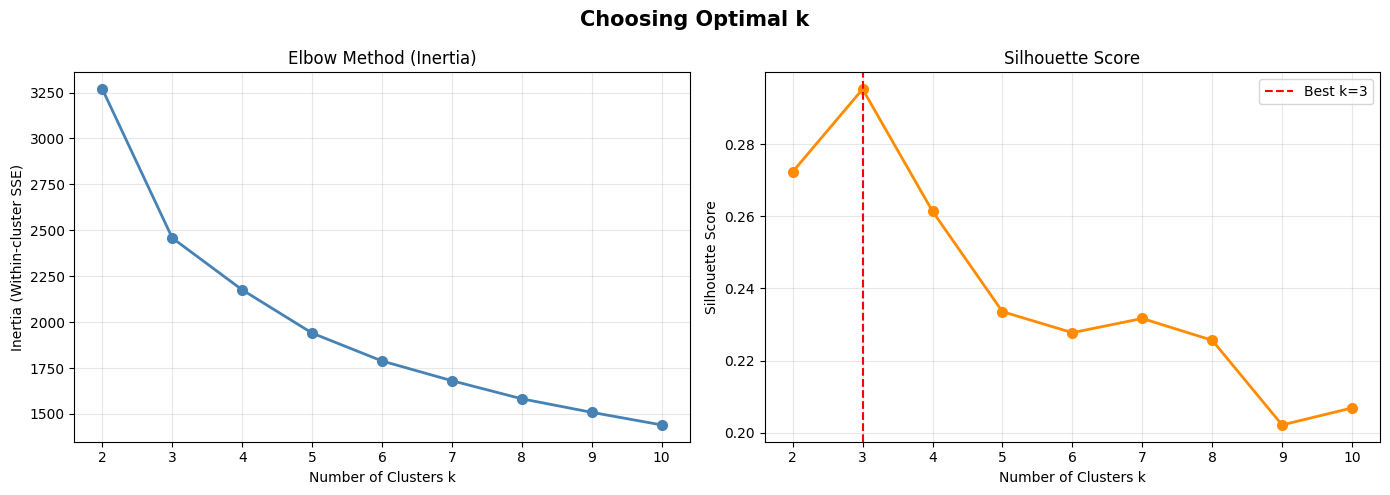


Best k by Silhouette Score: 3  (score=0.2953)


In [8]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Choosing Optimal k", fontsize=15, fontweight="bold")

# Elbow
axes[0].plot(list(k_range), inertias, "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of Clusters k")
axes[0].set_ylabel("Inertia (Within-cluster SSE)")
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(k_range), sil_scores, "o-", color="darkorange", linewidth=2, markersize=7)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

# Mark the best silhouette
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
axes[1].legend()

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nBest k by Silhouette Score: {best_k}  (score={max(sil_scores):.4f})")


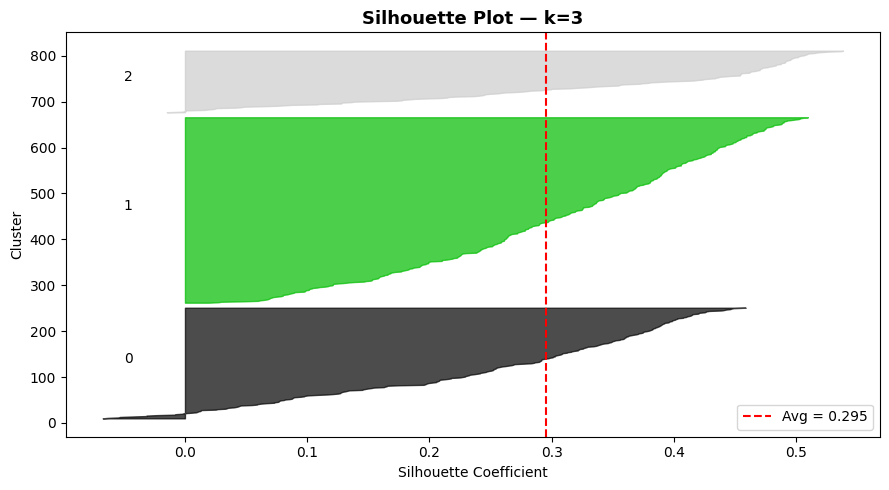

In [9]:
K_FINAL = best_k   # use the silhouette-recommended k

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
labels_final = km_final.fit_predict(X_scaled)
combined["cluster"] = labels_final

# Silhouette per-sample plot
sample_sil = silhouette_samples(X_scaled, labels_final)
fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
colors = cm.nipy_spectral(np.linspace(0, 1, K_FINAL))

for i in range(K_FINAL):
    sil_vals = np.sort(sample_sil[labels_final == i])
    size = sil_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

avg = silhouette_score(X_scaled, labels_final)
ax.axvline(avg, color="red", linestyle="--", label=f"Avg = {avg:.3f}")
ax.set_title(f"Silhouette Plot — k={K_FINAL}", fontsize=13, fontweight="bold")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.savefig("silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()


Variance explained: PC1=45.9%, PC2=23.4%, Total=69.2%


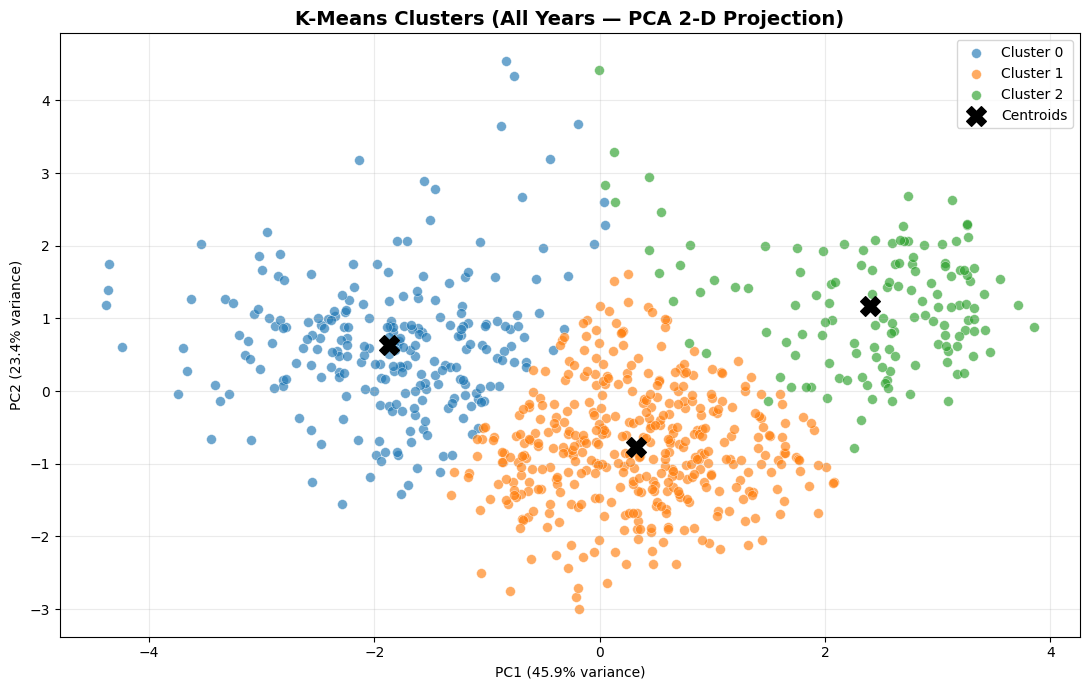

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
combined["pca_1"] = X_pca[:, 0]
combined["pca_2"] = X_pca[:, 1]

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette("tab10", K_FINAL)

for c in range(K_FINAL):
    mask = combined["cluster"] == c
    ax.scatter(combined.loc[mask, "pca_1"], combined.loc[mask, "pca_2"],
               color=palette[c], label=f"Cluster {c}", alpha=0.65, s=50, edgecolors="white", linewidth=0.4)

# Mark centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           s=200, c="black", marker="X", zorder=5, label="Centroids")

ax.set_title("K-Means Clusters (All Years — PCA 2-D Projection)", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(loc="best", framealpha=0.8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("pca_clusters_all_years.png", dpi=150, bbox_inches="tight")
plt.show()


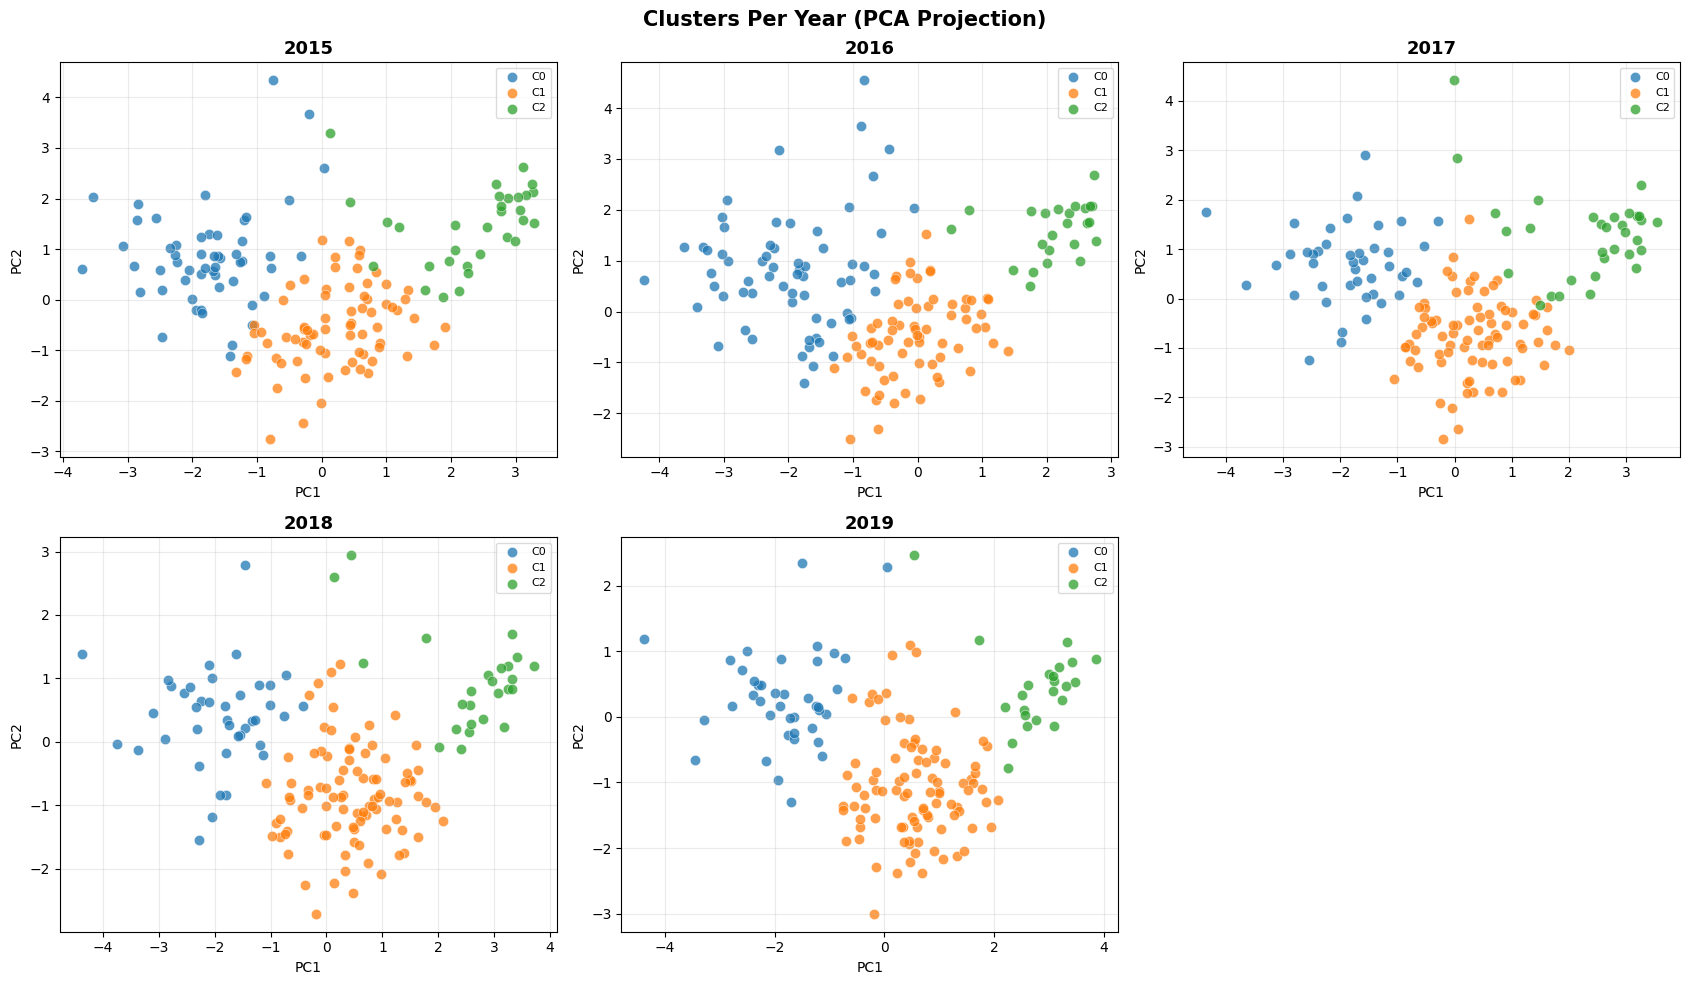

In [11]:
years = [2015, 2016, 2017, 2018, 2019]
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, yr in enumerate(years):
    ax = axes[i]
    subset = combined[combined["year"] == yr]
    for c in range(K_FINAL):
        mask = subset["cluster"] == c
        ax.scatter(subset.loc[mask, "pca_1"], subset.loc[mask, "pca_2"],
                   color=palette[c], label=f"C{c}", alpha=0.75, s=55,
                   edgecolors="white", linewidth=0.4)
    ax.set_title(str(yr), fontsize=13, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
    ax.grid(True, alpha=0.25)

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle("Clusters Per Year (PCA Projection)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("pca_clusters_per_year.png", dpi=150, bbox_inches="tight")
plt.show()


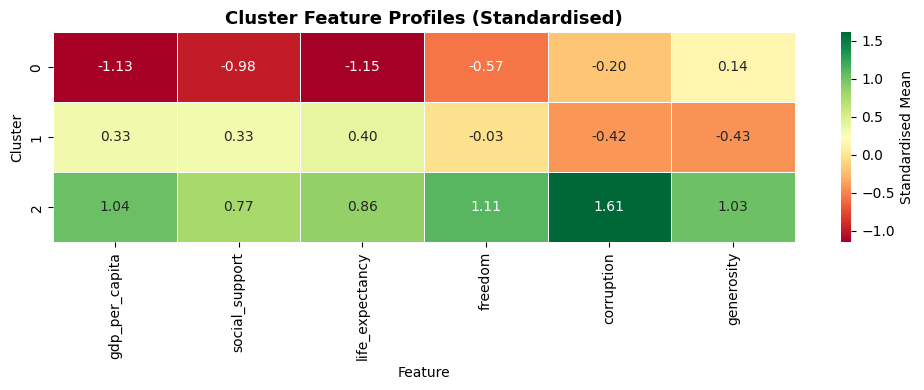

In [15]:
profile = combined.groupby("cluster")[CLUSTER_FEATURES].mean()
profile_scaled = pd.DataFrame(
    scaler.transform(profile),
    index=profile.index,
    columns=CLUSTER_FEATURES
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profile_scaled, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Standardised Mean"})
ax.set_title("Cluster Feature Profiles (Standardised)", fontsize=13, fontweight="bold")
ax.set_xlabel("Feature"); ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


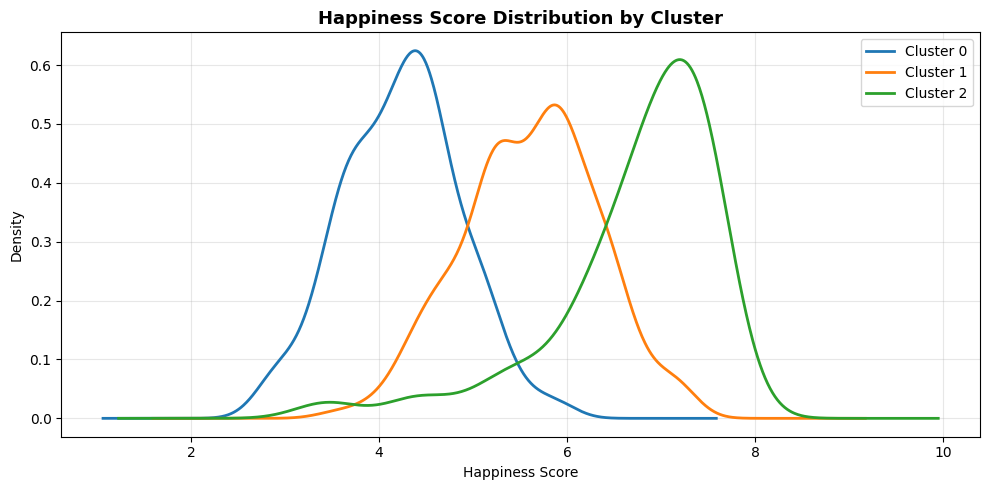


Cluster Summaries:
         n_records  avg_happiness  min_happiness  max_happiness
cluster                                                        
0              242          4.235          2.693          5.956
1              405          5.613          3.488          7.278
2              135          6.729          3.408          7.769


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for c in range(K_FINAL):
    subset = combined[combined["cluster"] == c]["happiness_score"]
    subset.plot(kind="kde", ax=ax, color=palette[c], label=f"Cluster {c}", linewidth=2)

ax.set_title("Happiness Score Distribution by Cluster", fontsize=13, fontweight="bold")
ax.set_xlabel("Happiness Score")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("happiness_dist_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# Print cluster summaries
print("\nCluster Summaries:")
print(combined.groupby("cluster")["happiness_score"]
      .agg(["count", "mean", "min", "max"])
      .rename(columns={"count": "n_records", "mean": "avg_happiness",
                       "min": "min_happiness", "max": "max_happiness"})
      .round(3))


In [13]:
top5 = (
    combined.groupby(["cluster", "country"])["happiness_score"]
    .mean()
    .reset_index()
    .sort_values(["cluster", "happiness_score"], ascending=[True, False])
)

for c in range(K_FINAL):
    print(f"\nCluster {c} — top 5:")
    print(top5[top5["cluster"] == c].head(5).to_string(index=False))



Cluster 0 — top 5:
 cluster  country  happiness_score
       0   Belize            5.956
       0  Moldova            5.897
       0  Bolivia            5.822
       0   Kosovo            5.495
       0 Pakistan            5.344

Cluster 1 — top 5:
 cluster        country  happiness_score
       1         Israel          7.22425
       1 United Kingdom          7.19000
       1     Costa Rica          7.12620
       1    Puerto Rico          7.03900
       1  United States          6.89200

Cluster 2 — top 5:
 cluster     country  happiness_score
       2     Denmark           7.5460
       2      Norway           7.5410
       2     Finland           7.5378
       2 Switzerland           7.5114
       2     Iceland           7.5110


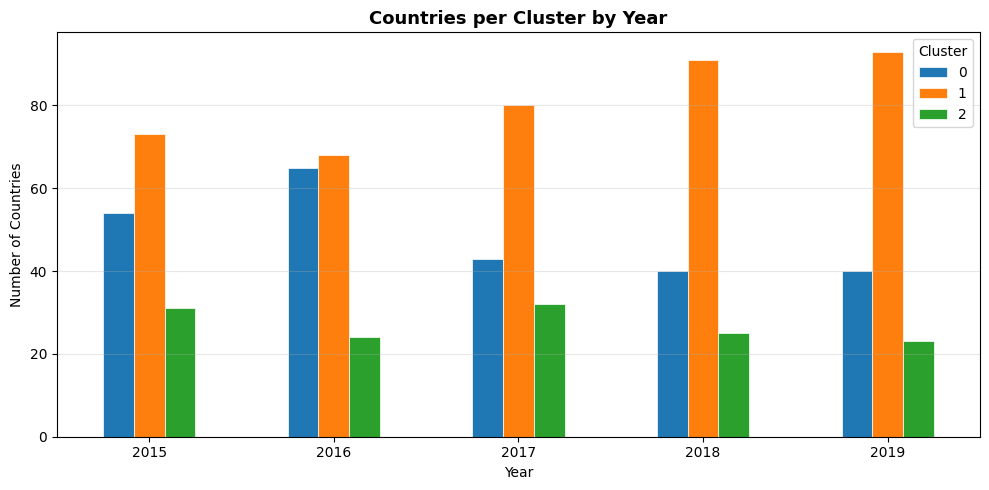

In [14]:
yearly_counts = (
    combined.groupby(["year", "cluster"])
    .size()
    .reset_index(name="count")
    .pivot(index="year", columns="cluster", values="count")
    .fillna(0)
)

ax = yearly_counts.plot(kind="bar", figsize=(10, 5), color=palette,
                        edgecolor="white", linewidth=0.5)
ax.set_title("Countries per Cluster by Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Number of Countries")
ax.legend(title="Cluster", loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("cluster_composition_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
